<a href="https://colab.research.google.com/github/Sneha8126/Python-Assignment/blob/main/Assignment_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/taxi_trip_pricing.csv')

In [ ]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180


In [ ]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [ ]:
df.isnull().sum()

,0
Trip_Distance_km,50
Time_of_Day,50
Day_of_Week,50
Passenger_Count,50
Traffic_Conditions,50
Weather,50
Base_Fare,50
Per_Km_Rate,50
Per_Minute_Rate,50
Trip_Duration_Minutes,50


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB


In [ ]:
numeric_cols = ['Trip_Distance_km', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate', 'Trip_Duration_Minutes','Passenger_Count']
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
cat_cols = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:

df.dropna(subset=['Trip_Price'], inplace=True)

In [ ]:
df.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,951.000000,951.000000,951.000000,951.000000,951.000000,951.000000,951.000000
mean,27.119442,2.455310,3.498160,1.229474,0.293701,62.035237,56.874773
std,19.619921,1.077937,0.846433,0.419888,0.112392,31.529372,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,13.130000,2.000000,2.765000,0.870000,0.200000,36.650000,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,37.830000,3.000000,4.170000,1.580000,0.390000,87.875000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [ ]:
df.isnull().sum()

,0
Trip_Distance_km,0
Time_of_Day,0
Day_of_Week,0
Passenger_Count,0
Traffic_Conditions,0
Weather,0
Base_Fare,0
Per_Km_Rate,0
Per_Minute_Rate,0
Trip_Duration_Minutes,0


In [ ]:
df.shape

(951, 11)

In [ ]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,Clear,3.48,0.51,0.15,116.81,36.4698
4,25.83,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
5,8.64,Afternoon,Weekend,2.0,Medium,Clear,2.55,1.71,0.48,89.33,60.2028


In [ ]:
df['Time_of_Day'].value_counts()

,count
Time_of_Day,
Afternoon,400
Morning,265
Evening,197
Night,89


In [ ]:
df['Day_of_Week'].value_counts()

,count
Day_of_Week,
Weekday,668
Weekend,283


In [ ]:
df['Traffic_Conditions'].value_counts()

,count
Traffic_Conditions,
Low,424
Medium,355
High,172


In [ ]:
df['Weather'].value_counts()

,count
Weather,
Clear,680
Rain,216
Snow,55


In [ ]:
traffic_map = {
    'Low': 0,
    'Medium': 1,
    'High': 2
}
df['Traffic_Conditions'] = df['Traffic_Conditions'].map(traffic_map)

In [ ]:
df = pd.get_dummies(df, columns=['Weather'], drop_first=True)

In [ ]:
time_map = {
    'Morning': 0,
    'Afternoon': 1,
    'Evening': 2,
    'Night': 3
}
df['Time_of_Day'] = df['Time_of_Day'].map(time_map)

In [ ]:
day_map = {
    'Weekday': 0,
    'Weekend': 1
}

df['Day_of_Week'] = df['Day_of_Week'].map(day_map)

In [ ]:
df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price,Weather_Rain,Weather_Snow
0,19.35,0,0,3.0,0,3.56,0.80,0.32,53.82,36.2624,False,False
2,36.87,2,1,1.0,2,2.70,1.21,0.15,37.27,52.9032,False,False
3,30.33,2,0,4.0,0,3.48,0.51,0.15,116.81,36.4698,False,False
4,25.83,2,0,3.0,2,2.93,0.63,0.32,22.64,15.6180,False,False
5,8.64,1,1,2.0,1,2.55,1.71,0.48,89.33,60.2028,False,False


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 951 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       951 non-null    float64
 1   Time_of_Day            951 non-null    int64  
 2   Day_of_Week            951 non-null    int64  
 3   Passenger_Count        951 non-null    float64
 4   Traffic_Conditions     951 non-null    int64  
 5   Base_Fare              951 non-null    float64
 6   Per_Km_Rate            951 non-null    float64
 7   Per_Minute_Rate        951 non-null    float64
 8   Trip_Duration_Minutes  951 non-null    float64
 9   Trip_Price             951 non-null    float64
 10  Weather_Rain           951 non-null    bool   
 11  Weather_Snow           951 non-null    bool   
dtypes: bool(2), float64(7), int64(3)
memory usage: 83.6 KB


In [ ]:
int_col = df.describe().columns
int_col

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate',
       'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [ ]:
int_df = df[int_col]
int_df.head()

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,0,0,3.0,0,3.56,0.80,0.32,53.82,36.2624
2,36.87,2,1,1.0,2,2.70,1.21,0.15,37.27,52.9032
3,30.33,2,0,4.0,0,3.48,0.51,0.15,116.81,36.4698
4,25.83,2,0,3.0,2,2.93,0.63,0.32,22.64,15.6180
5,8.64,1,1,2.0,1,2.55,1.71,0.48,89.33,60.2028


<Axes: >

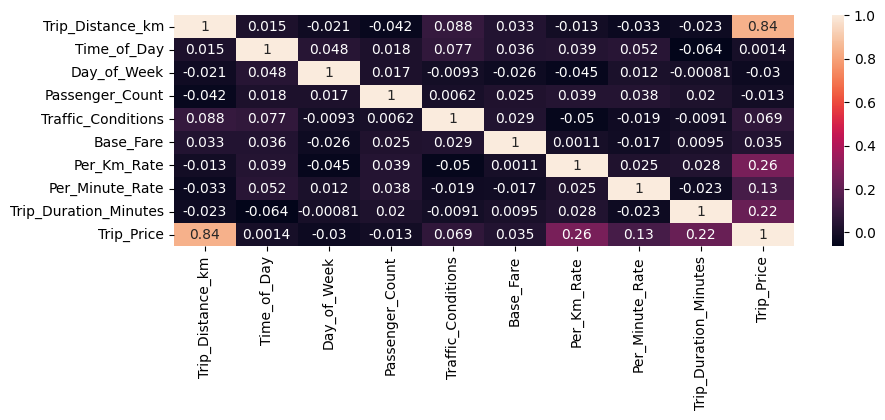

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,3))
sns.heatmap(int_df.corr(),annot=True)

In [ ]:
x = df.drop('Trip_Price',axis = 1)
y = df['Trip_Price']

In [ ]:
numerical_features = x.select_dtypes(include=["int64", "float64"]).columns
categorical_features = x.select_dtypes(include=["object"]).columns

print("Numerical Columns:")
print(numerical_features)

print("\nCategorical Columns:")
print(categorical_features)

Numerical Columns:
Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Base_Fare', 'Per_Km_Rate', 'Per_Minute_Rate',
       'Trip_Duration_Minutes'],
      dtype='object')

Categorical Columns:
Index([], dtype='object')


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42)

In [ ]:
x_train.shape

(760, 11)

In [ ]:
x_test.shape

(191, 11)

In [ ]:
y_train.shape

(760,)

In [ ]:
y_test.shape

(191,)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Linear Regression

In [ ]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score :", r2_score(y_test, y_pred))

MAE : 9.841491451940295
MSE : 286.84932103816084
RMSE : 16.936626613294656
R2 Score : 0.8772773526104319


# Ridge

In [ ]:
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)

ridge.fit(x_train, y_train)

ridge_pred = ridge.predict(x_test)

print("MAE :", mean_absolute_error(y_test, ridge_pred))
print("MSE :", mean_squared_error(y_test, ridge_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2 Score :", r2_score(y_test, ridge_pred))


MAE : 9.833065732702687
MSE : 287.39920325740883
RMSE : 16.952852363464057
R2 Score : 0.8770420966877254


# Lasso

In [ ]:
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)

lasso.fit(x_train, y_train)

lasso_pred = lasso.predict(x_test)

print("MAE :", mean_absolute_error(y_test, lasso_pred))
print("MSE :", mean_squared_error(y_test, lasso_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R2 Score :", r2_score(y_test, lasso_pred))



MAE : 9.813457149245345
MSE : 288.26308479959175
RMSE : 16.97831218936652
R2 Score : 0.8766725025415585


# Result

In [ ]:

results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ]
})

print(results)

               Model  R2 Score       RMSE
0  Linear Regression  0.877277  16.936627
1              Ridge  0.877042  16.952852
2              Lasso  0.876673  16.978312


In [ ]:
from sklearn.model_selection import cross_val_score

model = LinearRegression()

scores = cross_val_score(model, x, y, cv=5, scoring="r2")

print(scores)
print("Average R2 Score:", scores.mean())

[0.88101182 0.86255013 0.82589408 0.88217174 0.7513216 ]
Average R2 Score: 0.8405898731425967


In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {"alpha": [0.01, 0.1, 1, 10, 100]}

grid_ridge = GridSearchCV(
    Ridge(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_ridge.fit(x_train, y_train)

print(grid_ridge.best_params_)
print(grid_ridge.best_score_)

{'alpha': 10}
0.8490263995309915


In [ ]:
param_grid = {"alpha": [0.001, 0.01, 0.1, 1, 10]}

grid_lasso = GridSearchCV(
    Lasso(),
    param_grid,
    cv=5,
    scoring="r2"
)

grid_lasso.fit(x_train, y_train)

print(grid_lasso.best_params_)
print(grid_lasso.best_score_)

{'alpha': 0.1}
0.849041099909756


In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, ridge_pred),
        r2_score(y_test, lasso_pred)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred),
        mean_absolute_error(y_test, ridge_pred),
        mean_absolute_error(y_test, lasso_pred)
    ],
    "MSE":[
        mean_squared_error(y_test, y_pred),
        mean_squared_error(y_test, ridge_pred),
        mean_squared_error(y_test, lasso_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred)),
        np.sqrt(mean_squared_error(y_test, ridge_pred)),
        np.sqrt(mean_squared_error(y_test, lasso_pred))
    ]
})

print(results)

               Model  R2 Score       MAE         MSE       RMSE
0  Linear Regression  0.877277  9.841491  286.849321  16.936627
1              Ridge  0.877042  9.833066  287.399203  16.952852
2              Lasso  0.876673  9.813457  288.263085  16.978312
